In [ ]:
# program		ramirezXavier_finalNB_fishData_engr213.ipynb
# purpose	    Demonstrate visualization, binary classification, and clustering
#               on the seth_gov_envData10dtsMetrics_genusCount2026.csv for the
#               final report in ENGR 213. With Korbin Brashears.
# notes         (1) Techniques include: confusion matrix, NMDS, Decision Tree 
#               Classifier, and ROC curve.
#               (2) The NMDS plot compares different data preprocessing methods: environmental
#               versus genus attributes.
#               (3) Standardized
#               (4) Genus and environmental attributes are reduced separately.
#               (5) The arrows show the correlation of the original features with the reduced dimensions.
#               (6) The Decision Tree Classifier is trained to predict the presence of Gambusia based on the selected features.
#               (7) Copilot AI use is acknowledged for code debugging and optimization, but the overall structure and logic of 
#               the code were developed independently. AI was used as a tool to enhance code efficiency and readability, but the 
#               core analytical approach and interpretation of results were solely my work.
# date			4/30/2026 
# programmer    Xavier Ramirez

# <a id='toc1_'></a>[ramirezXavier_finalNB_fishData_engr213_ipynb](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [ramirezXavier_finalNB_fishData_engr213_ipynb](#toc1_)    
- [Imports](#toc2_)    
- [Decision Tree Classifier (DT)](#toc3_)    
  - [DT Preprocessing](#toc3_1_)    
  - [Decision Tree Classifier](#toc3_2_)    
  - [Visualization: Correlation Heatmap](#toc3_3_)    
  - [ROC Curve for Gambusia](#toc3_4_)    
  - [Feature Importance from DT](#toc3_5_)    
- [Non-Metric Multidimensional Scaling (NMDS)](#toc4_)    
  - [NMDS Preprocessing](#toc4_1_)    
  - [Bar Chart of Mean Environmental Attribute Values Across All Sites](#toc4_2_)    
  - [Bar Chart of Mean Genus Counts](#toc4_3_)    
  - [Stacked Bar Chart of Genus Composition Per Site](#toc4_4_)    
  - [Non-Metric Multidimensional Scaling (NMDS)](#toc4_5_)    
  - [NMDS Environmental Attribute Plot with Correlation Arrows](#toc4_6_)    
  - [NMDS Genus Attribute Plot with Correlation Arrows](#toc4_7_)    
- [Conclusion](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Imports](#toc0_)

In [2]:
# Imports for this report
# Python 3.10.19
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.manifold import MDS

Above are all of the imports required for this report and the Python version I used. I adapted two .py scripts into .ipynb format: ramirezXavier_demo_decisionTreeBinary_fishData.py and ramirezXavier_demo_dimReduction_fromSeminar_fishData.py. I a

The .csv file I used out of the many that exist for the Fish Data project is: seth_gov_envData10dtsMetrics_genusCount2026.csv. While there are a few different ones, this one was easiest for me to use for this report.

# <a id='toc3_'></a>[Decision Tree Classifier (DT)](#toc0_)

This first section comes from the script ramirezXavier_demo_decisionTreeBinary_fishData.py.



## <a id='toc3_1_'></a>[DT Preprocessing](#toc0_)

In [3]:
# ============== COMMON INITIALIZATION =====================
fileName_c = 'C:/Users/xavie/anaconda3/Scripts/Python XR 2304/FishProject/data/seth_gov_envData10dtsMetrics_genusCount2026.csv'

# ================= GET ALL DATA ======================
fish_df = pd.read_csv((fileName_c))
fish_df.head()

# Binary target in Y
Y = (fish_df['Gambusia'] > 0).astype(int).to_numpy().ravel()
pc1_drivers = ['pbottom_Mud', 'pbottom_Cobble', 'maxMonthFlow_cfs', 'avgMonthFlow_cfs', 'upstreamCumDA_km2',
               'pbottom_SmGravel', 'slopePercent']
X_all = fish_df[pc1_drivers]
X_all_std = StandardScaler().fit_transform(X_all)
print("X_all shape:", X_all.shape)

# =============== GET TRAIN, TEST DATA ==================
X_train, X_test, Y_train, Y_test = train_test_split(X_all_std, Y, test_size = 0.3, random_state = 42)
print("\nX_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_all shape: (46, 7)

X_train: (32, 7)
Y_train: (32,)


I chose the top seven features from previous scripts that included the loadings and principal components from the data when running a Principal Component Analysis (PCA) dimensionality reduction algorithm. I decided that using every feature would be too cluttery, but using too little can give us weak results. I also decided that running a PCA algorithm and using the actual principal components instead of the data loadings would defeat the purpose of using specific features that can accurately predict whether a chosen genus (in this case, Gambusia) is present or absent in any given site.

## <a id='toc3_2_'></a>[Decision Tree Classifier](#toc0_)

In [4]:
# =============== Algorithm ( Decision Tree Classifier ) ==================
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Training (Decision Tree Classifier)
# Early stopping on validation set
dt_model.fit(X_train, Y_train)

# Predict (Decision Tree Classifier)
Y_prob = dt_model.predict_proba(X_test)[:, 1]
Y_pred = dt_model.predict(X_test)

# Evaluate (Decision Tree Classifier)
acc_dt = accuracy_score(Y_test, Y_pred)
f1_dt = f1_score(Y_test, Y_pred)
auc_dt = roc_auc_score(Y_test, Y_prob)

print('\nDecision Tree Metrics:')
print("Accuracy Score:", acc_dt)
print("F1 Score:", f1_dt)
print("AUC Score:", auc_dt)

# For correlation heatmap for visualization of feature relationships
# --- Compute correlation matrix ---
corr_matrix = X_all.corr(method='pearson')


Decision Tree Metrics:
Accuracy Score: 0.8571428571428571
F1 Score: 0.9090909090909091
AUC Score: 0.787878787878788


The accuracy and F1 Scores are relatively high for using a small test train split and having 46 sites, so that is a good sign. The AUC (Area Under the Curve) score can range between .5 and 1, and a .7879 score shows that while the algorithm is acceptable and does find meaningful patterns, it is not strong enought to separate between presence and absence for Gambusia. Changing the genus to another and altering the test train split do change the AUC score significantly as well, even if the accuracy and F1 scores are relatively decent.

## <a id='toc3_3_'></a>[Visualization: Correlation Heatmap](#toc0_)

Text(0.5, 1.0, 'Environmental Correlation Heatmap')

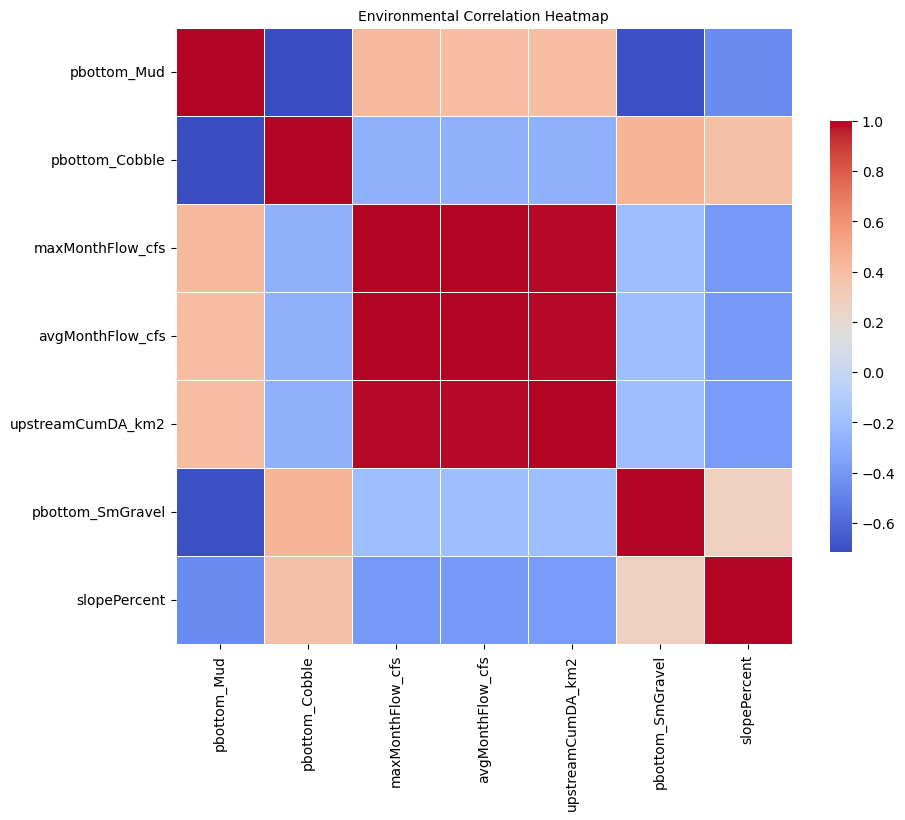

In [5]:
# PLOTTING
plt.figure(figsize=(10, 8))
# 1. Correlation Heatmap
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.7},
)
plt.title("Environmental Correlation Heatmap", fontsize=10)


The correlation heatmap above is a visualization of the chosen attributes for this section. The two flow and upstreamCumDA attributes seem to have strong correlation with each other, as can be seen by the 9 middle squares being dark red.

## <a id='toc3_4_'></a>[ROC Curve for Gambusia](#toc0_)

Text(0.5, 1.0, 'Decision Tree ROC Curve for Gambusia')

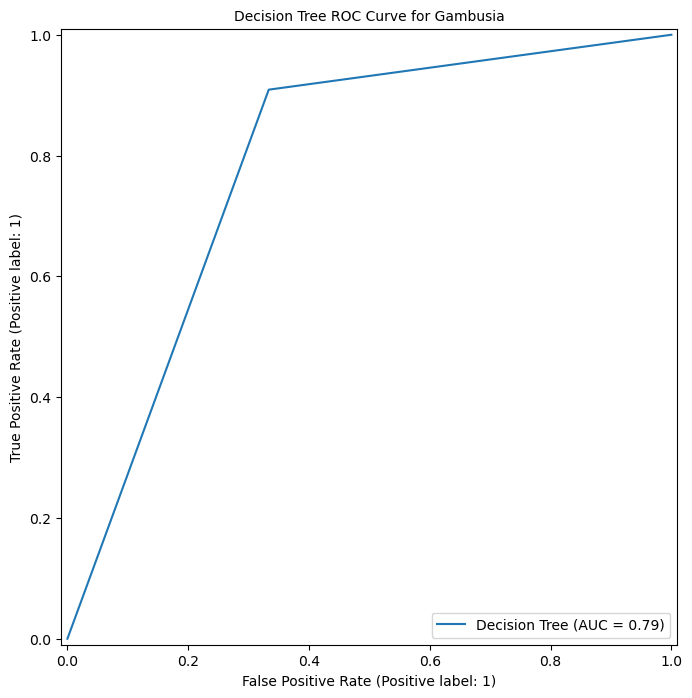

In [6]:
# 2. ROC Curve
plt.figure(figsize=(10, 8))
RocCurveDisplay.from_estimator(dt_model, X_test, Y_test, ax=plt.gca(), name="Decision Tree")
plt.title("Decision Tree ROC Curve for Gambusia", fontsize=10)

Above is the visual for the ROC curve that gives us the AUC score of .79 for Gambusia. 

## <a id='toc3_5_'></a>[Feature Importance from DT](#toc0_)

Text(0.5, 1.0, 'Decision Tree Feature Importance')

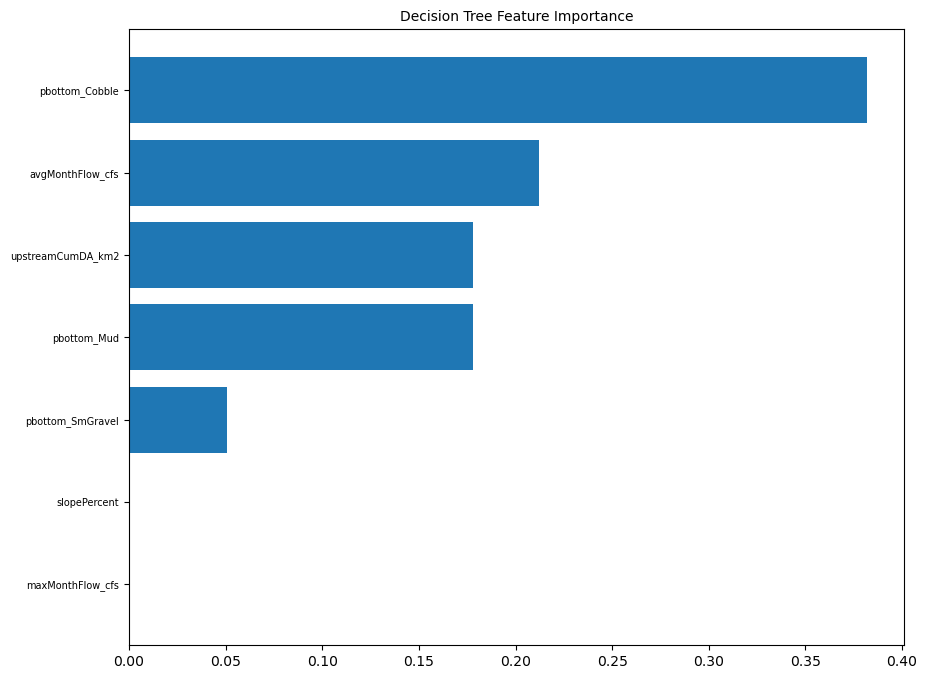

In [7]:
# 3. Feature Importance
plt.figure(figsize=(10, 8))
importances = dt_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
top_k = min(12, len(sorted_idx))
top_idx = sorted_idx[:top_k]
top_names = X_all.columns[top_idx]
top_vals = importances[top_idx]

plt.barh(range(top_k), top_vals[::-1])
plt.yticks(range(top_k), top_names[::-1], fontsize=7)
plt.title("Decision Tree Feature Importance", fontsize=10)

The Feature Importance plot above shows that the pbottom_Cobble attribute is a strong component in predicting whether there is presense or absence of Gambusia genus in any given site.

# <a id='toc4_'></a>[Non-Metric Multidimensional Scaling (NMDS)](#toc0_)

## <a id='toc4_1_'></a>[NMDS Preprocessing](#toc0_)

In [8]:
# ================= GET ALL DATA ======================
fish_df = pd.read_csv(fileName_c)

# Preprocessing for attributes and labels
state_ohe = pd.get_dummies(fish_df["State"], prefix="State")
X_fish = pd.concat([fish_df.iloc[:, 4:25]], axis=1) # 26 to 55 for genus
X_fish_std = StandardScaler().fit_transform(X_fish)
cat = fish_df["State"].astype("category")
y_fish = cat.cat.codes.values
target_names_fish = cat.cat.categories.tolist()

print("X_fish shape:", X_fish_std.shape)
print("y_fish shape:", y_fish.shape)
print("State categories:", target_names_fish)

# Genus as attributes below
X_genus = fish_df.iloc[:, 26:55]          # genus columns
X_genus_std = StandardScaler().fit_transform(X_genus)

X_fish shape: (46, 21)
y_fish shape: (46,)
State categories: ['OK', 'TX']


Above is two different X-components; X_fish is the environmental attributes from the .csv as its components, and X_genus is each genus as attributes for this section of code. This section is derived from the ramirezXavier_demo_dimReduction_fromSeminar_fishData.py script.

## <a id='toc4_2_'></a>[Bar Chart of Mean Environmental Attribute Values Across All Sites](#toc0_)


C:\Users\xavie\AppData\Local\Temp\ipykernel_15132\2209747741.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attr_means.values, y=attr_means.index, palette="viridis")


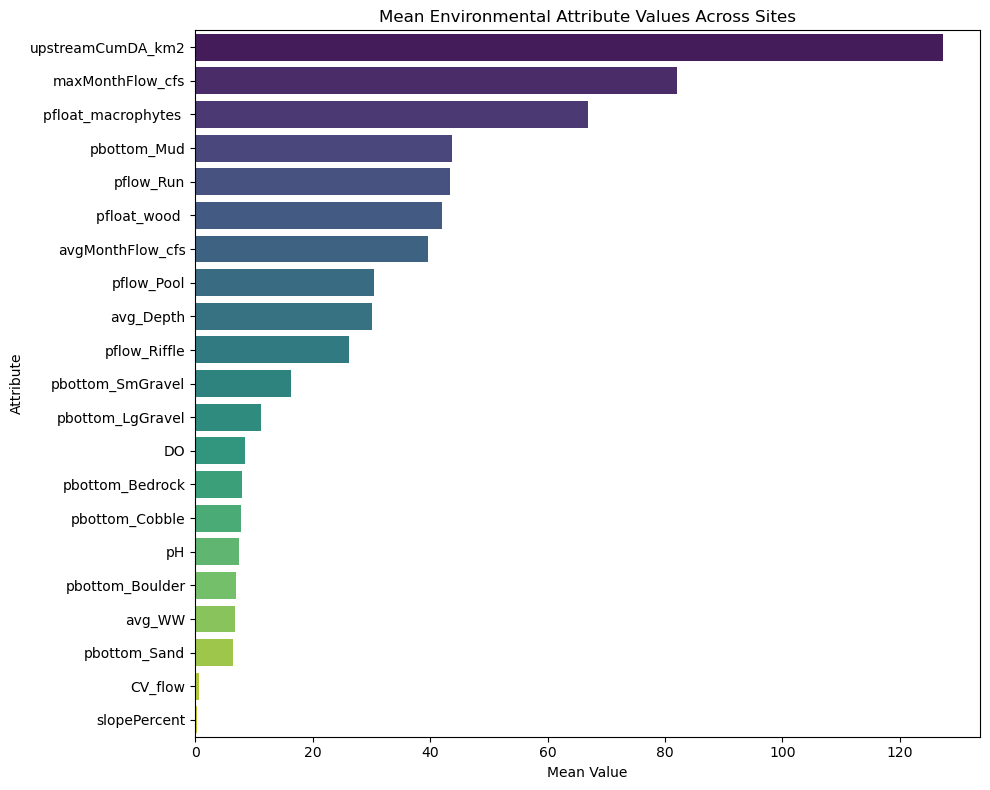

In [9]:
# Column names for attributes
attr_cols = fish_df.columns[4:25]

# Compute mean per attribute
attr_means = fish_df[attr_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=attr_means.values, y=attr_means.index, palette="viridis")
plt.title("Mean Environmental Attribute Values Across Sites")
plt.xlabel("Mean Value")
plt.ylabel("Attribute")
plt.tight_layout()
plt.show()

Above is a simple visualization of each feature's mean value across all sites put into one bar chart. It shows the average value for every attribute, which does not show much individually per site but does have consistent values in terms of attributes such as minimal slopePercent and pbottom_Mud being the highest amongst all pbottom attributes.

## <a id='toc4_3_'></a>[Bar Chart of Mean Genus Counts](#toc0_)

C:\Users\xavie\AppData\Local\Temp\ipykernel_15132\131402551.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genus_means.values, y=genus_means.index, palette="magma")


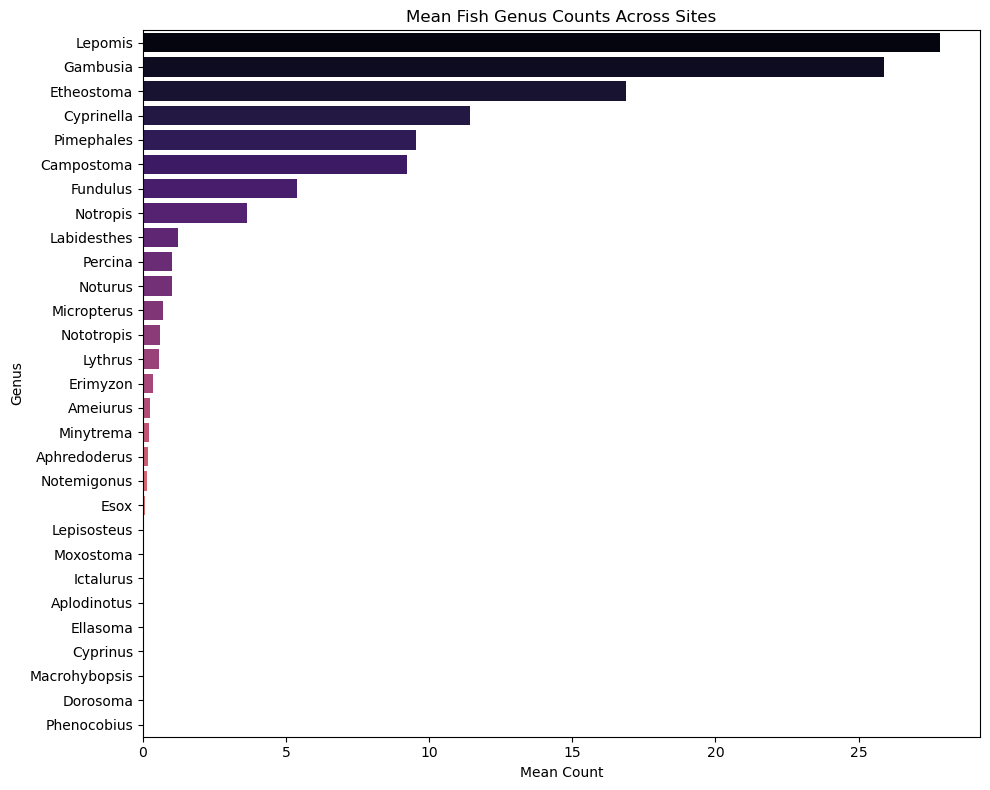

In [10]:
# Column names for genera
genus_cols = fish_df.columns[26:55]

genus_means = fish_df[genus_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=genus_means.values, y=genus_means.index, palette="magma")
plt.title("Mean Fish Genus Counts Across Sites")
plt.xlabel("Mean Count")
plt.ylabel("Genus")
plt.tight_layout()
plt.show()

Above is the average amount of each genus present at each site, which confirms that the top eight genus of fish out-populate every other fish throughout the entire Northeast Texas and Southeast Oklahoma region.

## <a id='toc4_4_'></a>[Stacked Bar Chart of Genus Composition Per Site](#toc0_)

<Figure size 1000x800 with 0 Axes>

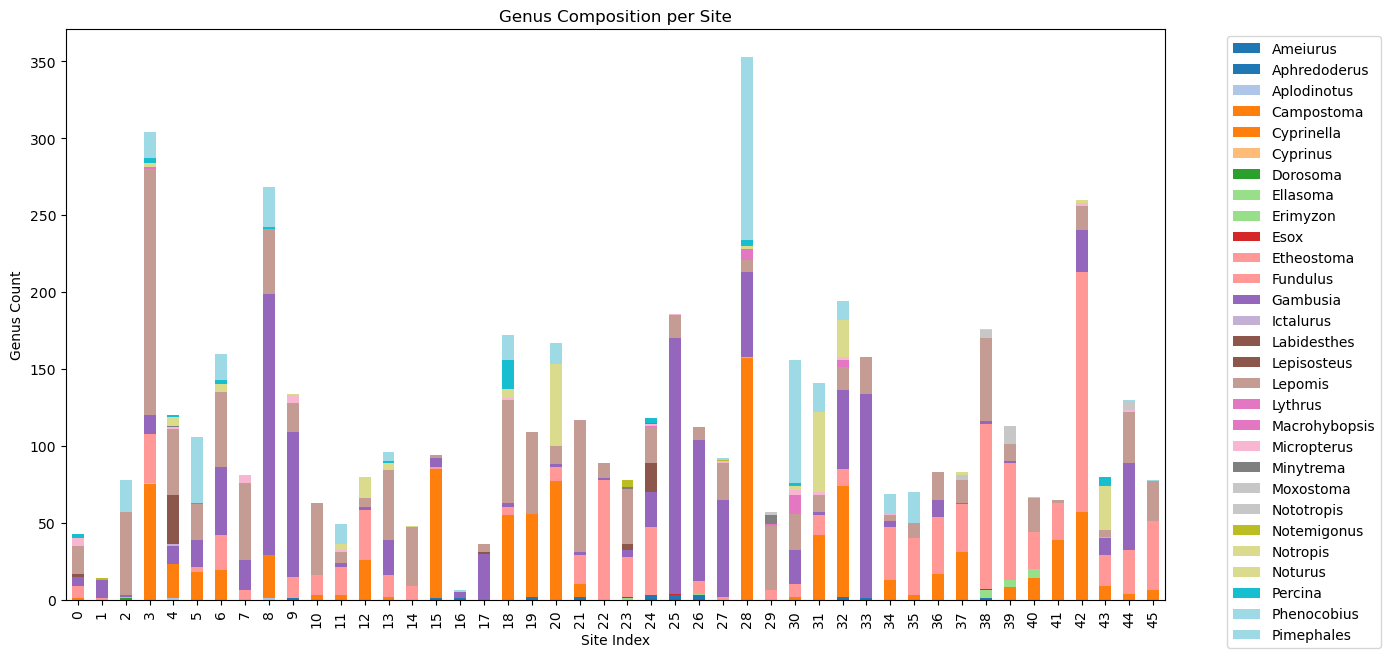

In [11]:
plt.figure(figsize=(10, 8))

fish_df[genus_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    colormap="tab20"
)

plt.title("Genus Composition per Site")
plt.xlabel("Site Index")
plt.ylabel("Genus Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Above shows a visual of all genera of fish throughout every site, assigning each genus to a color. The results from this visual are consistent with Gambusia, Pimephales, Cyprinella, Etheostoma, and Lepomis as being predominant genera throughout every site.

## <a id='toc4_5_'></a>[Non-Metric Multidimensional Scaling (NMDS)](#toc0_)

In [12]:
# ======================== APPLY DIMENSIONALITY REDUCTION TECHNIQUES ======================
nmds_env = MDS(metric=False, n_components=2, random_state=10, dissimilarity='euclidean')
X_fish_nmds = nmds_env.fit_transform(X_fish_std)

nmds_genus = MDS(metric=False, n_components=2, random_state=5, dissimilarity='euclidean')
X_genus_nmds = nmds_genus.fit_transform(X_genus_std)

c:\Users\xavie\anaconda3\envs\fish\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
c:\Users\xavie\anaconda3\envs\fish\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


NMDS is applied to both X-components to create two different plots below.

## <a id='toc4_6_'></a>[NMDS Environmental Attribute Plot with Correlation Arrows](#toc0_)

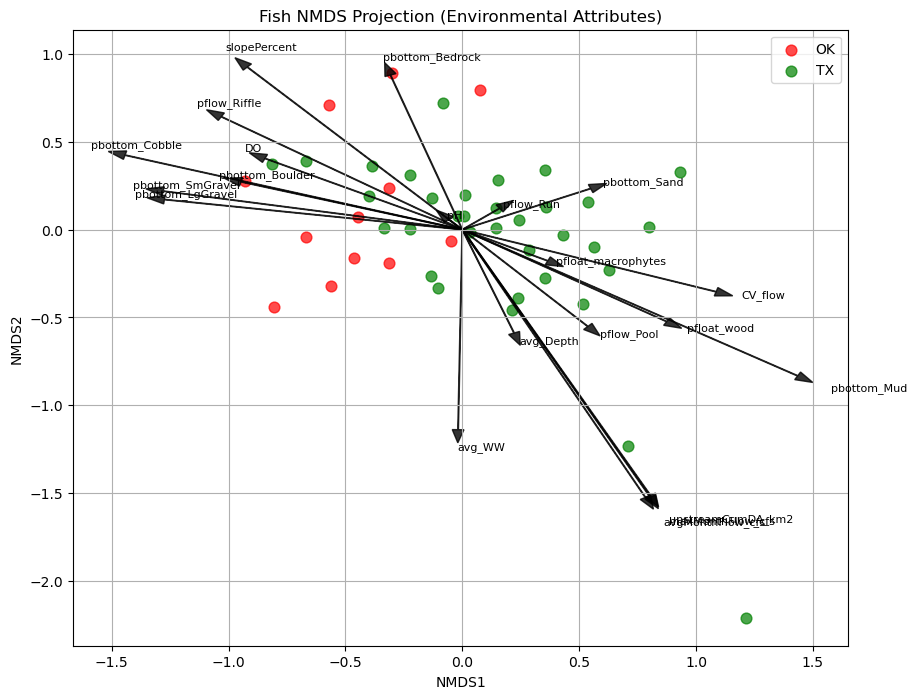

In [13]:
colors = ['red','green','blue', 'magenta', 'cyan', 'yellow', 'orange', 'purple', 'brown', 'pink']

plt.figure(figsize=(10, 8))

# Scatter by state
for label, color in zip(np.unique(y_fish), colors):
    plt.scatter(X_fish_nmds[y_fish==label, 0],
                X_fish_nmds[y_fish==label, 1],
                label=target_names_fish[label],
                alpha=0.7, s=60, color=color)

# Compute correlations
feature_names_env = X_fish.columns
corrs_env = np.zeros((X_fish_std.shape[1], 2))

for i in range(X_fish_std.shape[1]):
    cor_x = np.corrcoef(X_fish_std[:, i], X_fish_nmds[:, 0])[0, 1]
    cor_y = np.corrcoef(X_fish_std[:, i], X_fish_nmds[:, 1])[0, 1]
    corrs_env[i] = [cor_x, cor_y]

# Scale arrows
arrow_scale_env = 0.8 * np.max(np.abs(X_fish_nmds))

# Plot arrows
for i, (cx, cy) in enumerate(corrs_env):
    plt.arrow(0, 0,
              cx * arrow_scale_env,
              cy * arrow_scale_env,
              color='black',
              width=0.003,
              head_width=0.05,
              alpha=0.8)
    plt.text(cx * arrow_scale_env * 1.1,
             cy * arrow_scale_env * 1.1,
             feature_names_env[i],
             fontsize=8)

plt.title("Fish NMDS Projection (Environmental Attributes)")
plt.xlabel("NMDS1")
plt.ylabel("NMDS2")
plt.grid(True)
plt.legend()

Above is a not-so-strong clustering of Oklahoma vs. Texas sites, differentiated by color, with correlation arrows overlaid on top of the scatterplot. While the clustering is not strong, the arrows do show general correlations between either left-side pointing arrows (for Oklahoma) or right-side pointing arrows (for Texas). I think some tweaking or picking specific attributes instead of using every attribute could produce different results, but I have not tested that yet.

## <a id='toc4_7_'></a>[NMDS Genus Attribute Plot with Correlation Arrows](#toc0_)

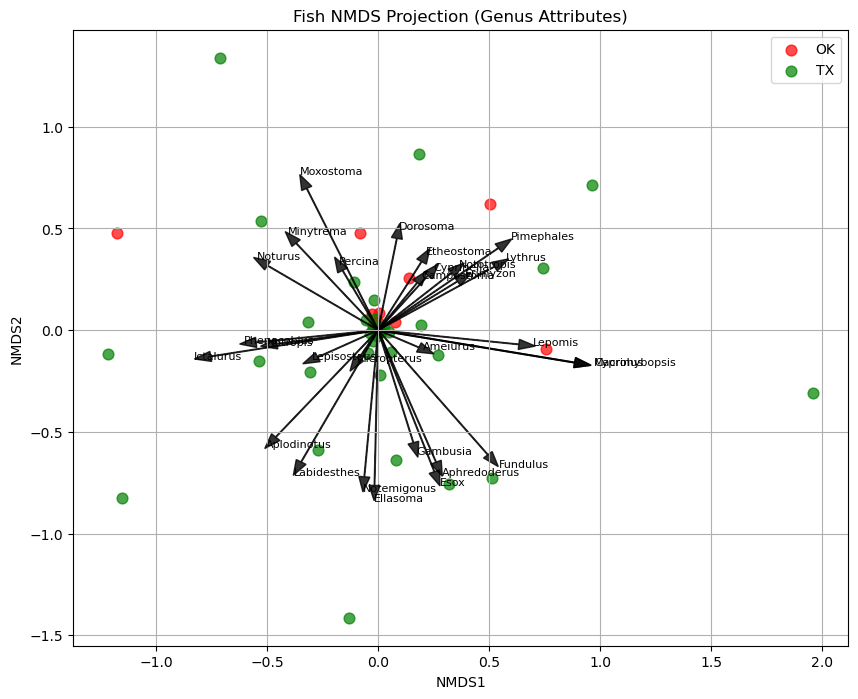

In [14]:
plt.figure(figsize=(10, 8))

for label, color in zip(np.unique(y_fish), colors):
    plt.scatter(X_genus_nmds[y_fish==label, 0],
                X_genus_nmds[y_fish==label, 1],
                label=target_names_fish[label],
                alpha=0.7, s=60, color=color)

# Compute correlations
feature_names_genus = X_genus.columns
corrs_genus = np.zeros((X_genus_std.shape[1], 2))

for i in range(X_genus_std.shape[1]):
    cor_x = np.corrcoef(X_genus_std[:, i], X_genus_nmds[:, 0])[0, 1]
    cor_y = np.corrcoef(X_genus_std[:, i], X_genus_nmds[:, 1])[0, 1]
    corrs_genus[i] = [cor_x, cor_y]

# Scale arrows
arrow_scale_genus = 0.8 * np.max(np.abs(X_genus_nmds))

# Plot arrows
for i, (cx, cy) in enumerate(corrs_genus):
    plt.arrow(0, 0,
              cx * arrow_scale_genus,
              cy * arrow_scale_genus,
              color='black',
              width=0.003,
              head_width=0.05,
              alpha=0.8)
    plt.text(cx * arrow_scale_genus * 1.1,
             cy * arrow_scale_genus * 1.1,
             feature_names_genus[i],
             fontsize=8)

plt.title("Fish NMDS Projection (Genus Attributes)")
plt.xlabel("NMDS1")
plt.ylabel("NMDS2")
plt.grid(True)
plt.legend()

Above is a similar overlay of scatterplot and correlation arrows except for the genus as attributes across all sites differentiating between Texas and Oklahoma. These results are much weaker, as can be seen by the sporadic distribution of each site, minimal correlation between red and green dots, and the various genera of fish arrows being spread quite evenly across all directions and having a similar length all around. This is because many genera have such low populations, which others are much more abundant throughout every site, which can lead to extreme variation in clustering using every genus or extreme overfitting when running regressor models using ensemble methods between sites (which I mention because Korbin ran into this issue recently).

# <a id='toc5_'></a>[Conclusion](#toc0_)

Across all analyses, the results consistently show that both environmental conditions and genus‑level community structure contain meaningful but moderately overlapping ecological signals. The binary Decision Tree classifier achieved an AUC of 0.78, indicating solid discriminatory power and confirming that the environmental predictors capture real gradients relevant to site classification, even if the separation is not perfectly sharp. The NMDS ordinations of both the environmental attributes and the genus composition further reinforce this pattern: sites form distinguishable clusters in reduced dimensional space, but with expected ecological overlap that reflects natural variability rather than noise. Having only 46 sites also greatly affects accuracy and test train split results.

The visual analyses add important context; the environmental correlation heatmap revealed coherent physical relationships—strong positive associations among flow variables and drainage area, and expected negative correlations among substrate types due to compositional constraints. These patterns validate the internal consistency of the dataset and support the idea that the classifier is learning from meaningful structure rather than artifacts or pure memorization. Similarly, the genus barplots and stacked community compositions show clear differences in dominant genera across sites, suggesting that biological communities respond to the same gradients captured in the environmental data.

Taken together, the modeling, ordination, and visualization results converge on a consistent conclusion: the dataset contains real ecological structure that can be detected through both statistical learning and community‑level ordination. While the classifier’s performance indicates room for improvement, the combined evidence demonstrates that environmental gradients and genus composition jointly reflect underlying site differences in a biologically interpretable way. This integrated workflow of classification, ordination, and visualization provides a robust foundation for understanding how environmental conditions shape fish community patterns across sites. Some ideas to strengthen pattern findings could include changing test train splits, bagging to "add more data" by in a calculated manner, changing the variation of attributes as components, or adding more to pipeline by experimenting with principal components as attributes. 